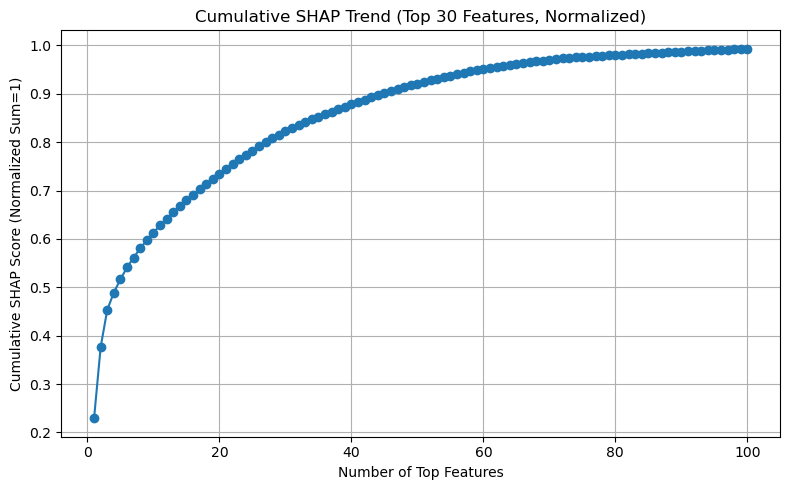

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 1. 读取 Excel
df = pd.read_excel("qf_final_feature_shap_values.xlsx")  # 替换为你的文件路径

# 2. 归一化处理（使用 softmax）
def softmax(x):
    e_x = np.exp(x - np.max(x))  # 避免数值爆炸
    return e_x / e_x.sum()

# 2. 普通归一化：使 Weighted_SHAP 总和为 1
df["Normalized_SHAP"] = df["Weighted_SHAP"] / df["Weighted_SHAP"].sum()
sample_num = 100
# 3. 按归一化分数排序，取前30个特征
df_top30 = df.sort_values("Normalized_SHAP", ascending=False).head(sample_num).reset_index(drop=True)

# 4. 计算累计归一化 SHAP 分数
df_top30["Cumulative_SHAP"] = df_top30["Normalized_SHAP"].cumsum()

# 5. 绘图
plt.figure(figsize=(8, 5))
plt.plot(range(1, 1+sample_num), df_top30["Cumulative_SHAP"], marker='o')
plt.xlabel("Number of Top Features")
plt.ylabel("Cumulative SHAP Score (Normalized Sum=1)")
plt.title("Cumulative SHAP Trend (Top 30 Features, Normalized)")
plt.grid(True)
plt.tight_layout()
plt.show()

In [2]:
print("Sum of Normalized_SHAP:", df["Normalized_SHAP"].sum())


Sum of Normalized_SHAP: 1.0000000000000004


In [3]:
print("Last cumulative value:", df_sorted["Cumulative_SHAP"].iloc[-1])


Last cumulative value: 1.000000000000005


In [13]:
from kneed import KneeLocator

knee = KneeLocator(
    range(1, len(df_sorted)+1),
    df_sorted["Cumulative_SHAP"],
    curve="concave",
    direction="increasing"
)

print("转折点位置：", knee.knee)


转折点位置： 2


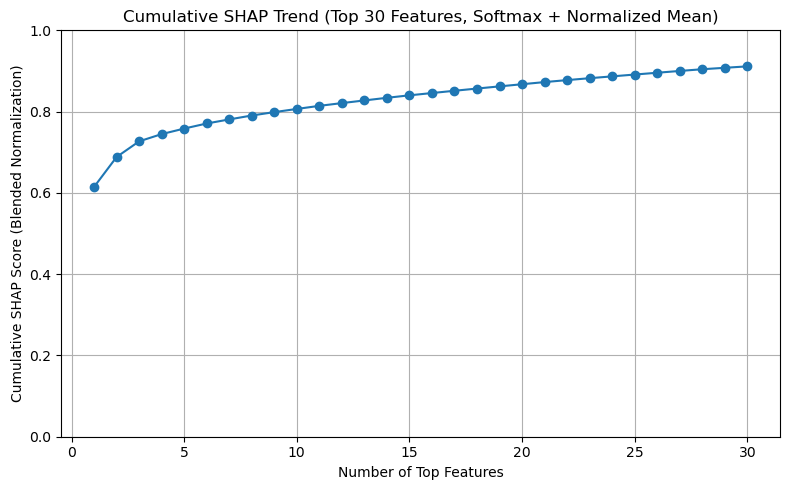

In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 1. 读取 Excel
df = pd.read_excel("qf_final_feature_shap_values.xlsx")  # 替换为你的文件路径

# 2. 归一化处理（使用 softmax）
def softmax(x):
    e_x = np.exp(x - np.max(x))  # 避免数值爆炸
    return e_x / e_x.sum()
# 2. 普通归一化
normal_norm = df["Weighted_SHAP"] / df["Weighted_SHAP"].sum()

# 3. Softmax归一化
def softmax(x):
    e_x = np.exp(x - np.max(x))
    return e_x / e_x.sum()

softmax_norm = softmax(df["Weighted_SHAP"].values)

# 4. 融合两者：取平均
df["Normalized_SHAP"] = (normal_norm + softmax_norm) / 2
num_sample = 30
# 5. 排序并取Top 30
df_top30 = df.sort_values("Normalized_SHAP", ascending=False).head(num_sample).reset_index(drop=True)

# 6. 累计求和
df_top30["Cumulative_SHAP"] = df_top30["Normalized_SHAP"].cumsum()

# 7. 绘图
plt.figure(figsize=(8, 5))
plt.plot(range(1, num_sample + 1), df_top30["Cumulative_SHAP"], marker='o')
plt.xlabel("Number of Top Features")
plt.ylabel("Cumulative SHAP Score (Blended Normalization)")
plt.title("Cumulative SHAP Trend (Top 30 Features, Softmax + Normalized Mean)")
plt.ylim(0,1)
plt.grid(True)
plt.tight_layout()
plt.show()
df_top30.to_excel('feature_top30_qf.xlsx')

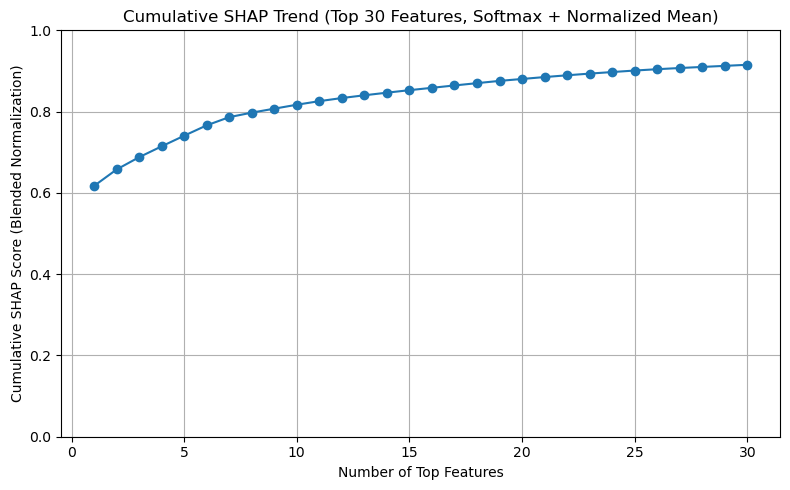

In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 1. 读取 Excel
df = pd.read_excel("kl_final_feature_shap_values.xlsx")  # 替换为你的文件路径

# 2. 归一化处理（使用 softmax）
def softmax(x):
    e_x = np.exp(x - np.max(x))  # 避免数值爆炸
    return e_x / e_x.sum()

# 2. 普通归一化
normal_norm = df["Weighted_SHAP"] / df["Weighted_SHAP"].sum()

# 3. Softmax归一化
def softmax(x):
    e_x = np.exp(x - np.max(x))
    return e_x / e_x.sum()

softmax_norm = softmax(df["Weighted_SHAP"].values)

# 4. 融合两者：取平均
df["Normalized_SHAP"] = (normal_norm + softmax_norm) / 2
num_sample = 30
# 5. 排序并取Top 30
df_top30 = df.sort_values("Normalized_SHAP", ascending=False).head(num_sample).reset_index(drop=True)

# 6. 累计求和
df_top30["Cumulative_SHAP"] = df_top30["Normalized_SHAP"].cumsum()

# 7. 绘图
plt.figure(figsize=(8, 5))
plt.plot(range(1, num_sample + 1), df_top30["Cumulative_SHAP"], marker='o')
plt.xlabel("Number of Top Features")
plt.ylabel("Cumulative SHAP Score (Blended Normalization)")
plt.title("Cumulative SHAP Trend (Top 30 Features, Softmax + Normalized Mean)")
plt.ylim(0,1)
plt.grid(True)
plt.tight_layout()
plt.show()
df_top30.to_excel('feature_top30_kl.xlsx')

In [30]:
import numpy as np
for i in [0.0039,0.00086,0.00678,0.00306]:
    print(np.sqrt(i))

0.06244997998398398
0.02932575659723036
0.0823407554009556
0.05531726674375732
